In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter
from scipy.stats import skew, kurtosis
from python_speech_features import mfcc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

#https://www.kaggle.com/datasets/mozillaorg/common-voice

In [2]:
def train_or_load_model(x,y,model_type, method):
    model = None
    model_path = model_type + " classification models/" + model_type + "_model_" + method + ".pkl"
    if os.path.exists(model_path):
        print("Model file found. Loading existing age model...")
        model = joblib.load(model_path)
    else:
        print(f"Model file not found. Training and saving a new {model_type} model using {method}...")
        match method:
            case "RFC":
                model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
            case "KNN":
                model = KNeighborsClassifier(n_neighbors=5)
            case "SVM":
                model = SVC(class_weight='balanced', kernel='linear', random_state=42)
        model.fit(x,y)
        joblib.dump(model, model_path)
    return model

In [6]:
NUM_SAMPLES = 5000
data= pd.read_csv("cv-valid-train.csv")
data=data.dropna(subset=["gender","age"])
data = data.sample(n = NUM_SAMPLES, random_state=42)
data.head()
print(data.shape[0])
print(data["age"].unique())

5000
['twenties' 'fourties' 'seventies' 'sixties' 'thirties' 'teens' 'fifties'
 'eighties']


In [7]:


# Ambient Noise Reduction (Low-pass filter)
def butter_lowpass_filter(data, cutoff=3000, fs=16000, order=6):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

# Vocal Enhancement (simple gain normalization)
def vocal_enhancement(y):
    return y / np.max(np.abs(y))

# Feature Extraction Function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    
    # Audio Trimming
    y, _ = librosa.effects.trim(y)

    # Ambient Noise Reduction
    y = butter_lowpass_filter(y, fs=sr)

    # Vocal Enhancement
    y = vocal_enhancement(y)

    # Feature Extraction
    mfcc_feat = mfcc(y, sr, numcep=13)
    mfcc_mean = np.mean(mfcc_feat, axis=0)
    mfcc_std = np.std(mfcc_feat, axis=0)
    mfcc_skew = skew(mfcc_feat, axis=0)
    #mfcc_kurt = kurtosis(mfcc_feat, axis=0)
    
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch = pitches[magnitudes > np.median(magnitudes)]  # remove low confidence
    pitch_mean = np.mean(pitch) if pitch.size else 0
    pitch_std = np.std(pitch) if pitch.size else 0 
    
    zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y))
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    #stft_feat = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    
    return np.hstack([mfcc_mean, mfcc_std, mfcc_skew,
        pitch_mean, pitch_std, zero_crossing_rate, spectral_centroid])

# Load Dataset (Common Voice)
dataset_path = "cv-valid-train/"
newdata = []
gender_labels = []
age_labels = []

age_encoder=LabelEncoder()
age_encoder.fit(data["age"].unique())
for index,row in data.iterrows() :  
    if row["filename"].endswith(".mp3"):
        try:
            features = extract_features(dataset_path + row["filename"])
            gender = row["gender"]  # 'male' or 'female'
            age = row["age"]  # numerical age
            newdata.append(features)
            gender_labels.append(1 if gender == 'male' else 0)
            age_labels.append(age_encoder.transform([age])[0])
        except Exception as e:
            print(f"Error processing {dataset_path + row['filename']}: {e}")

# Convert to NumPy Arrays
newdata = np.array(newdata)
gender_labels = np.array(gender_labels)
age_labels = np.array(age_labels)


Model file found. Loading existing age model...


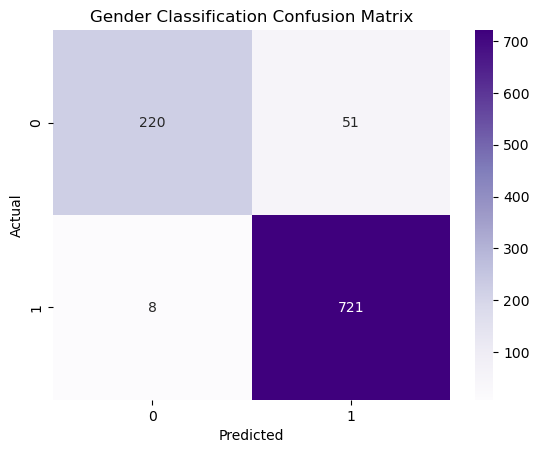

Gender Classification Report:
              precision    recall  f1-score   support

      Female       0.96      0.81      0.88       271
        Male       0.93      0.99      0.96       729

    accuracy                           0.94      1000
   macro avg       0.95      0.90      0.92      1000
weighted avg       0.94      0.94      0.94      1000

Accuracy: 0.9410
Model file found. Loading existing age model...


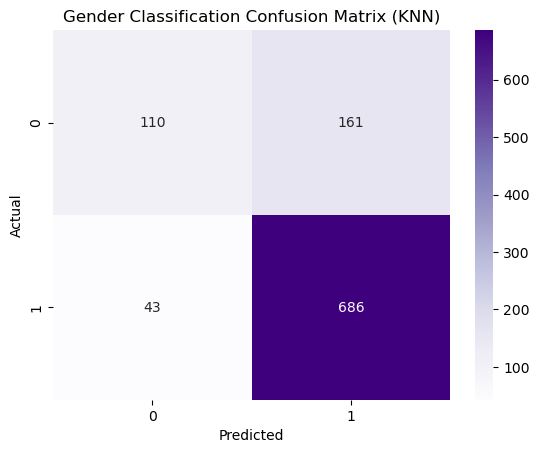

Gender Classification Report (KNN):
              precision    recall  f1-score   support

      Female       0.72      0.41      0.52       271
        Male       0.81      0.94      0.87       729

    accuracy                           0.80      1000
   macro avg       0.76      0.67      0.69      1000
weighted avg       0.79      0.80      0.78      1000

Accuracy (KNN): 0.7960
Model file not found. Training and saving a new gender model using SVM...


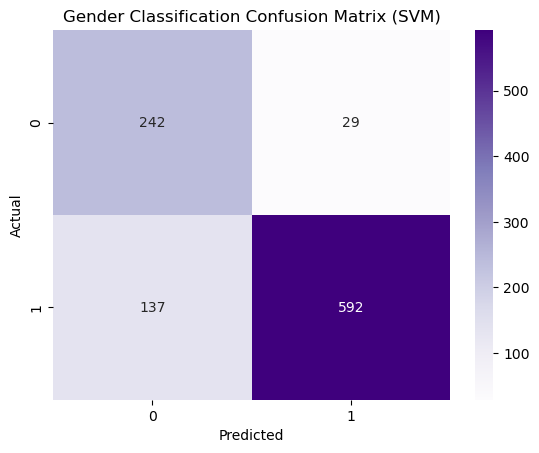

Gender Classification Report (SVM):
              precision    recall  f1-score   support

      Female       0.64      0.89      0.74       271
        Male       0.95      0.81      0.88       729

    accuracy                           0.83      1000
   macro avg       0.80      0.85      0.81      1000
weighted avg       0.87      0.83      0.84      1000

Accuracy (SVM): 0.8340


In [9]:
# Split Data for Gender Classification
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(newdata, gender_labels, test_size=0.2, random_state=42)
# Train Random Forest for Gender
gender_model = train_or_load_model(X_train_g, y_train_g, model_type="gender", method="RFC")

y_pred_g = gender_model.predict(X_test_g)

# Confusion Matrix for Gender
cm_g = confusion_matrix(y_test_g, y_pred_g)
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Gender Classification Report:")
print(classification_report(y_test_g, y_pred_g, target_names=['Female', 'Male']))
accuracy = accuracy_score(y_test_g, y_pred_g)
print(f'Accuracy: {accuracy:.4f}')

##################################################################################################################################
# Train KNN for Gender
gender_model_knn = train_or_load_model(X_train_g, y_train_g, model_type="gender", method="KNN")

y_pred_g_knn = gender_model_knn.predict(X_test_g)

cm_g_knn = confusion_matrix(y_test_g, y_pred_g_knn)
sns.heatmap(cm_g_knn, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Gender Classification Report (KNN):")
print(classification_report(y_test_g, y_pred_g_knn, target_names=['Female', 'Male']))

accuracy_knn = accuracy_score(y_test_g, y_pred_g_knn)
print(f'Accuracy (KNN): {accuracy_knn:.4f}')
###################################################################################################################################
# Train SVM for Gender
# Use SVC (Support Vector Classifier)
gender_model_svm = train_or_load_model(X_train_g, y_train_g, model_type="gender", method="SVM")

# Make predictions
y_pred_g_svm = gender_model_svm.predict(X_test_g)

# Confusion Matrix for Gender
cm_g_svm = confusion_matrix(y_test_g, y_pred_g_svm)
sns.heatmap(cm_g_svm, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Gender Classification Report
print("Gender Classification Report (SVM):")
print(classification_report(y_test_g, y_pred_g_svm, target_names=['Female', 'Male']))

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_g, y_pred_g_svm)

# Print accuracy
print(f'Accuracy (SVM): {accuracy_svm:.4f}')


Model file found. Loading existing age model...


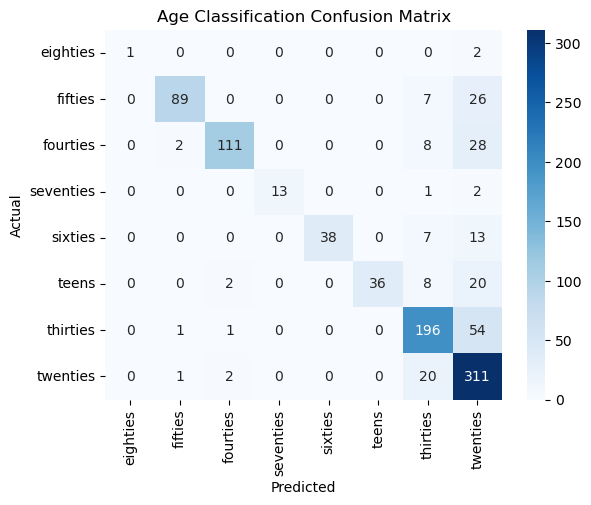

Age Classification Report:
              precision    recall  f1-score   support

    eighties       1.00      0.33      0.50         3
     fifties       0.96      0.73      0.83       122
    fourties       0.96      0.74      0.84       149
   seventies       1.00      0.81      0.90        16
     sixties       1.00      0.66      0.79        58
       teens       1.00      0.55      0.71        66
    thirties       0.79      0.78      0.79       252
    twenties       0.68      0.93      0.79       334

    accuracy                           0.80      1000
   macro avg       0.92      0.69      0.77      1000
weighted avg       0.83      0.80      0.80      1000

Accuracy: 0.7950
Model file found. Loading existing age model...
[0 1 2 3 4 5 6 7]


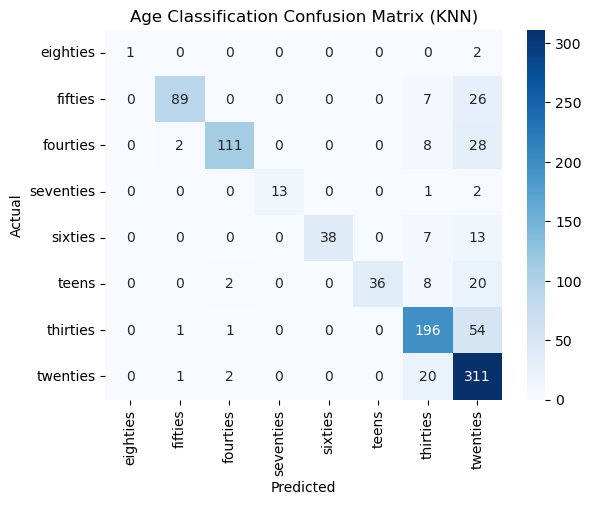

Age Classification Report (KNN):
              precision    recall  f1-score   support

    eighties       1.00      0.33      0.50         3
     fifties       0.96      0.73      0.83       122
    fourties       0.96      0.74      0.84       149
   seventies       1.00      0.81      0.90        16
     sixties       1.00      0.66      0.79        58
       teens       1.00      0.55      0.71        66
    thirties       0.79      0.78      0.79       252
    twenties       0.68      0.93      0.79       334

    accuracy                           0.80      1000
   macro avg       0.92      0.69      0.77      1000
weighted avg       0.83      0.80      0.80      1000

Accuracy (KNN): 0.7950
Model file found. Loading existing age model...


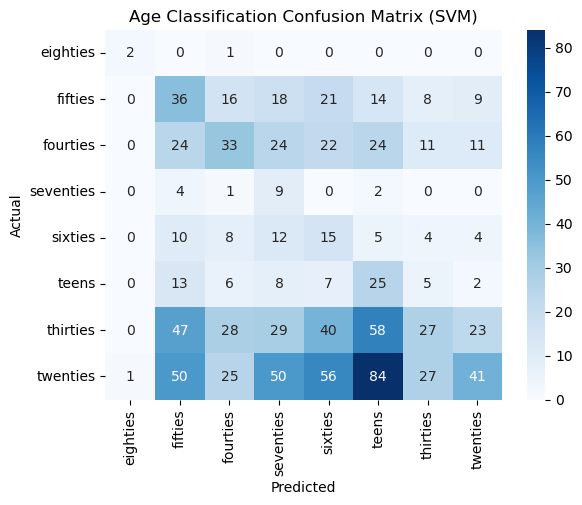

Age Classification Report (SVM):
              precision    recall  f1-score   support

    eighties       0.67      0.67      0.67         3
     fifties       0.20      0.30      0.24       122
    fourties       0.28      0.22      0.25       149
   seventies       0.06      0.56      0.11        16
     sixties       0.09      0.26      0.14        58
       teens       0.12      0.38      0.18        66
    thirties       0.33      0.11      0.16       252
    twenties       0.46      0.12      0.19       334

    accuracy                           0.19      1000
   macro avg       0.27      0.33      0.24      1000
weighted avg       0.32      0.19      0.19      1000

Accuracy (SVM): 0.1880


In [11]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(newdata, age_labels, test_size=0.2, random_state=42)

# Train Random Forest for Age
age_model = train_or_load_model(X_train_a, y_train_a, model_type="age", method="RFC")
y_pred_a = age_model.predict(X_test_a)

age_labels_str = list(age_encoder.classes_)
y_test_str = age_encoder.inverse_transform(y_test_a)
y_pred_str = age_encoder.inverse_transform(y_pred_a)

cm_a = confusion_matrix(y_test_str, y_pred_str, labels=age_labels_str)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Age Classification Report:")
print(classification_report(y_test_str, y_pred_str, target_names=age_labels_str))
accuracy = accuracy_score(y_test_str, y_pred_str)

# Print accuracy
print(f'Accuracy: {accuracy:.4f}')
#################################################################################################################################################################################################################
# Use KNeighborsClassifier instead of RandomForest
age_model_knn = train_or_load_model(X_train_a, y_train_a, model_type="age", method="KNN")

# Make predictions
y_pred_a_knn = age_model_knn.predict(X_test_a)

# Binning age for evaluation (discretize the predicted and true age labels)
age_bins = np.sort(age_encoder.fit_transform(data["age"].unique()))
print(age_bins)

age_labels_str = list(age_encoder.classes_)
y_test_str = age_encoder.inverse_transform(y_test_a)
y_pred_str = age_encoder.inverse_transform(y_pred_a)

# Confusion Matrix for Age (KNN)
cm_a_knn = confusion_matrix(y_test_str, y_pred_str, labels=age_labels_str)
sns.heatmap(cm_a_knn, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Age (KNN)
print("Age Classification Report (KNN):")
print(classification_report(y_test_str, y_pred_str, target_names=age_labels_str))

# Calculate accuracy
accuracy_knn = accuracy_score(y_test_str, y_pred_str)

# Print accuracy
print(f'Accuracy (KNN): {accuracy_knn:.4f}')
################################################################################################################################################################################################################## 
age_model_svm = train_or_load_model(X_train_a, y_train_a, model_type="age", method="SVM")

# Make predictions
y_pred_a = age_model_svm.predict(X_test_a)

age_labels_str = list(age_encoder.classes_)
y_test_str = age_encoder.inverse_transform(y_test_a)
y_pred_str = age_encoder.inverse_transform(y_pred_a)

# Confusion Matrix for Age Classification
cm_a = confusion_matrix(y_test_str, y_pred_str, labels=age_labels_str)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Age Classification Report
print("Age Classification Report (SVM):")
print(classification_report(y_test_str, y_pred_str, target_names=age_labels_str))

# Calculate accuracy
accuracy = accuracy_score(y_test_str, y_pred_str)

# Print accuracy
print(f'Accuracy (SVM): {accuracy:.4f}')